Predict the next three numbers (revisited 3):
- This example is the sequence-to-sequence prediction model that utilizes the Encoder-Decoder architecture.
- The model in this example is able to deal with variable time steps, both in the input and in the output. Using this model, the next number can be repeatedly predicted without any time step limitation.

# 1. Prepare the environment

In [1]:
# List all NVIDIA GPUs as available in this computer (or Colab's session)
!nvidia-smi -L

GPU 0: NVIDIA A100-SXM4-40GB (UUID: GPU-c9c36656-8d87-0d5b-7abe-b6f280424e5c)


In [2]:
import sys
print( f"Python {sys.version}\n" )

import numpy as np
print( f"NumPy {np.__version__}\n" )

import matplotlib.pyplot as plt
%matplotlib inline

# https://keras.io/getting_started/
# The backend must be configured before importing Keras, and the backend cannot be changed after the package has been imported.
import os
os.environ["KERAS_BACKEND"] = "torch"  # "jax", "tensorflow"

import keras
print(f"Keras {keras.__version__}")
print(f"|- Keras backend = {keras.backend.backend()}")
print(f"|- Keras backend image data format = {keras.backend.image_data_format()}\n")

import torch
print( f"PyTorch {torch.__version__}" )

# Get all available accelerators such as CUDA, MPS, MTIA, or XPU
num_accelerators = torch.accelerator.device_count()

if (num_accelerators <= 0):
    print("|- No hardware accelerators found. Using CPU only.")
else:
    print(f"|- PyTorch detected {num_accelerators} hardware accelerator(s)")
    print(f"|- PyTorch detected '{torch.accelerator.current_accelerator().type.upper()}' as the current accelerator")

    # Check cuda availability
    if torch.cuda.is_available():
        num_gpus = torch.cuda.device_count()
        print(f"|- PyTorch detected {num_gpus} CUDA GPU(s):")
    for i in range(num_gpus):
        print(f"   |- CUDA GPU {i}: {torch.cuda.get_device_name(i)}")

Python 3.12.11 (main, Jun  4 2025, 08:56:18) [GCC 11.4.0]

NumPy 2.0.2

Keras 3.10.0
|- Keras backend = torch
|- Keras backend image data format = channels_last

PyTorch 2.8.0+cu126
|- PyTorch detected 1 hardware accelerator(s)
|- PyTorch detected 'CUDA' as the current accelerator
|- PyTorch detected 1 CUDA GPU(s):
   |- CUDA GPU 0: NVIDIA A100-SXM4-40GB


In [3]:
import math
import time
import datetime

In [4]:
# Set fixed seeding values for reproducability during experiments
# Skip this cell if random initialization (with varied results) is needed

# https://keras.io/examples/keras_recipes/reproducibility_recipes/
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
#keras.utils.set_random_seed(1234)

# 2. Create the Encoder-Decoder RNN model

## 2.1 Create the unified model for training

In [5]:
# n_input: The cardinality of the input sequence (e.g. number of features, size of the word/character embedding vector)
# n_output: The cardinality of the output sequence (e.g. number of features, size of the word/character embedding vector)
# n_units: The number of cells (neurons) to create in the encoder and decoder models (e.g. 128 or 256)
n_input, n_output, n_units = 1, 1, 20

# Define the encoder
### Create all layers
encoder_inputs = keras.layers.Input( shape=(None,n_input), name='encoder_input_x' )
encoder_rnn = keras.layers.SimpleRNN( n_units, return_state=True, name='encoder_rnn' )
### Link all layers
encoder_outputs, encoder_states = encoder_rnn(encoder_inputs)

# Define the decoder
### Create all layers
decoder_inputs = keras.layers.Input( shape=(None,n_output), name='decoder_input_x' )
decoder_rnn = keras.layers.SimpleRNN( n_units, return_sequences=True, return_state=True, name='decoder_rnn' )
decoder_dense = keras.layers.Dense(n_output, name='decoder_dense')
### Link all layers
decoder_outputs, _ = decoder_rnn(decoder_inputs, initial_state=encoder_states)
decoder_outputs = decoder_dense(decoder_outputs)

# Define the unified Encoder-Decoder model for training
seq2seq_model = keras.Model( inputs=[encoder_inputs, decoder_inputs], outputs=decoder_outputs, name='seq2seq_model' )
seq2seq_model.summary()

Model: "seq2seq_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input_x     │ (None, None, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input_x     │ (None, None, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_rnn         │ [(None, 20),      │        440 │ encoder_input_x[… │
│ (SimpleRNN)         │ (None, 20)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_rnn         │ [(None, None,     │        440 │ decoder_input_x[… │
│ (SimpleRNN)         │ 20), (None, 20)]  │            │ encoder_rnn[0][1] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense       │ (None, None, 1)   │         21 │ decoder_rnn[0][0] │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 901 (3.52 KB)

 Trainable params: 901 (3.52 KB)

 Non-trainable params: 0 (0.00 B)

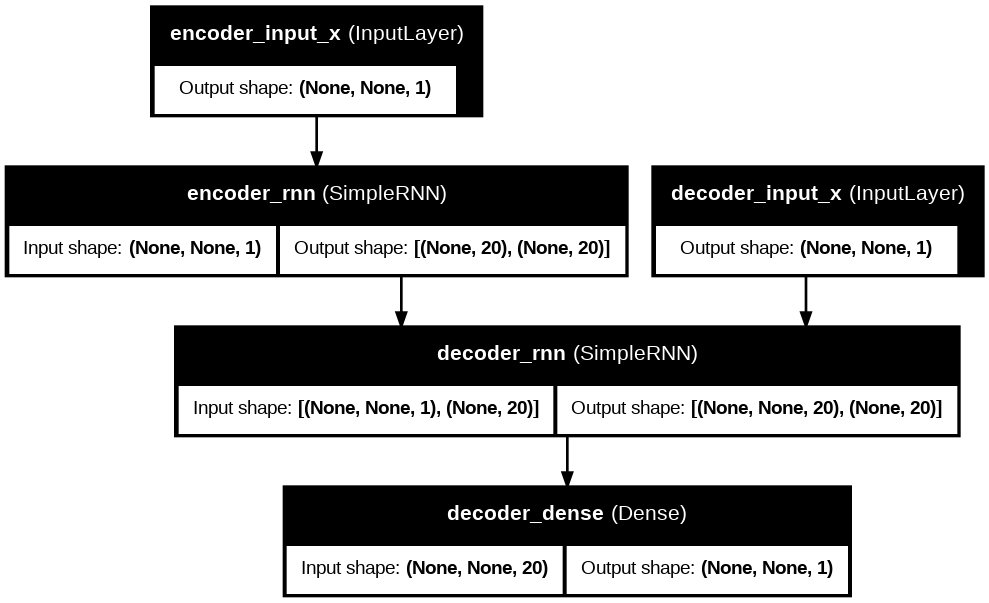

In [6]:
# Visualize the model
keras.utils.plot_model(seq2seq_model, "RNN_ex6_trainmodel.png", show_shapes=True, show_dtype=False, show_layer_names=True, dpi=96)

## 2.2 Create separated decoder and encoder models for inferencing

Model: "encoder_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input_x (InputLayer)    │ (None, None, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_rnn (SimpleRNN)         │ [(None, 20), (None,    │           440 │
│                                 │ 20)]                   │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 440 (1.72 KB)

 Trainable params: 440 (1.72 KB)

 Non-trainable params: 0 (0.00 B)

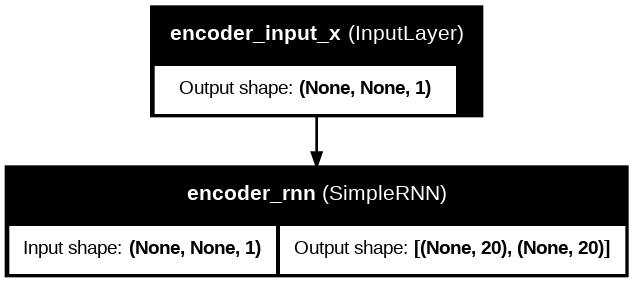

In [7]:
# Define the encoder-only model for inferencing
encoder_model = keras.Model(inputs=encoder_inputs, outputs=encoder_states, name='encoder_model')

encoder_model.summary()
keras.utils.plot_model(encoder_model, "RNN_ex6_encodermodel.png", show_shapes=True, show_dtype=False, show_layer_names=True, dpi=96)

Model: "decoder_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ decoder_input_x     │ (None, None, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input_state │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_rnn         │ [(None, None,     │        440 │ decoder_input_x[… │
│ (SimpleRNN)         │ 20), (None, 20)]  │            │ decoder_input_st… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense       │ (None, None, 1)   │         21 │ decoder_rnn[1][0] │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 461 (1.80 KB)

 Trainable params: 461 (1.80 KB)

 Non-trainable params: 0 (0.00 B)

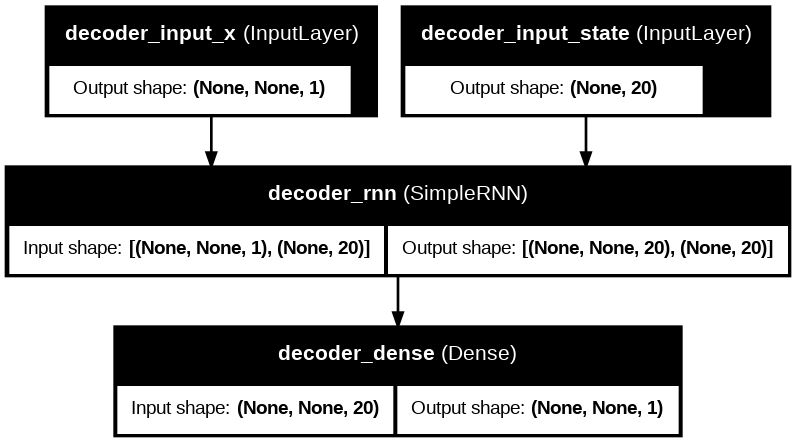

In [8]:
# Define the decoder-only model for inferencing
### Create a new input layer to be used during inferencing
decoder_states_inputs = keras.layers.Input( shape=((n_units,)), name='decoder_input_state' )
### Link all layers together
decoder_outputs, decoder_states = decoder_rnn(decoder_inputs, initial_state=decoder_states_inputs )
decoder_outputs = decoder_dense(decoder_outputs)
decoder_model = keras.Model( inputs=[decoder_inputs] + [decoder_states_inputs],
                             outputs=[decoder_outputs] + [decoder_states],
                             name='decoder_model' )

decoder_model.summary()
keras.utils.plot_model(decoder_model, "RNN_ex6_decodermodel.png", show_shapes=True, show_dtype=False, show_layer_names=True, dpi=96)

# 3. Create the dataset

- To train the unified `seq2seq_model` model, we need to prepare the following inputs and output:
  - **Input1:** `encoder_input_x` is an input sequence for the encoder (later we will refer to it as `encoder_x`).
  - **Input2:** `decoder_input_x` is an input sequence for the decoder (later we will refer to it as `decoder_x`).
  - **Output:** `decoder_dense.output` is a prediction output of the decoder (later we will refer to it as `decoder_y`).

- Values of `encoder_x` and `decoder_y` are straightforward. For example, one training sample with 5-step inputs and 3-step prediction outputs will be like `encoder_x[i] = [2, 4, 6, 8, 10]` and `decoder_y[i] = [12, 14, 16]`.

- The one whose value needs additional consideration is `decoder_x`. Here we use Teacher Forcing, the popular training technique in machine translation, so if `encoder_x[i] = [2, 4, 6, 8, 10]` and `decoder_y[i] = [12, 14, 16]`, then `decoder_x[i] = ['start', 12, 14]`

## 3.1 Create the original and normalized series

- Generate a 1D time series from `start_val` to `stop_val` with step 2:

In [9]:
start_val , stop_val = -4000 , 2000

# Create raw data
series = np.arange(start_val, stop_val+1, 2)
n_data = series.shape[0]

# Preview
print(f"{type(series)=} , {series.shape=} , {series}")

type(series)=<class 'numpy.ndarray'> , series.shape=(3001,) , [-4000 -3998 -3996 ...  1996  1998  2000]


- <u>Split the data from oldest to newest</u>: first 80% for training, next 10% for validation, last 10% for testing.
- Compute the training statistics (mean and SD) <u>using only the training portion</u>.
- Normalize the entire 1D sequence (z-score) using the training statistics.

In [10]:
# Split ratios
n_train = int(n_data * 0.8)         # 80% train
n_test = int(n_data * 0.1)          # 10% test
n_val = n_data - n_train - n_test   # 10% validation

# Compute training's mean and SD
train_mean = np.mean(series[:n_train])
train_std = np.std(series[:n_train])

# Normalize entire series using training stats
series_norm = (series - train_mean) / train_std
print(f"{type(series_norm)=} , {series_norm.shape=} , {series_norm}")

type(series_norm)=<class 'numpy.ndarray'> , series_norm.shape=(3001,) , [-1.73132927 -1.72988589 -1.72844252 ...  2.59591137  2.59735475
  2.59879812]


## 3.2 Prepare seq2seq training data with Teacher Forcing

In [11]:
# Parameters
n_input_timesteps = 5
n_output_timesteps = 3

# The start token should be outside the range of the data the decoder actually sees.
start_token = series.min() - 1              # slightly smaller than min
start_token_norm = series_norm.min() - 0.1  # slightly smaller than min
print(f"{start_token=}\n{start_token_norm=}\n")

# Initialize lists
encoder_x, decoder_x, decoder_y = [], [], []
encoder_x_norm, decoder_x_norm, decoder_y_norm = [], [], []

# Loop over the series
for i in range(len(series) - n_input_timesteps - n_output_timesteps + 1):
    # Encoder input
    enc_seq = series[i:i+n_input_timesteps]
    enc_seq_norm = series_norm[i:i+n_input_timesteps]

    # Decoder output (ground truth)
    dec_seq = series[i+n_input_timesteps : i+n_input_timesteps+n_output_timesteps]
    dec_seq_norm = series_norm[i+n_input_timesteps : i+n_input_timesteps+n_output_timesteps]

    # Decoder input (Teacher Forcing): shift right and prepend start token
    dec_input_seq = [start_token] + list( dec_seq[:-1] )
    dec_input_seq_norm = [start_token_norm] + list( dec_seq_norm[:-1] )

    # Append
    encoder_x.append(enc_seq)
    decoder_y.append(dec_seq)
    decoder_x.append(dec_input_seq)

    encoder_x_norm.append(enc_seq_norm)
    decoder_y_norm.append(dec_seq_norm)
    decoder_x_norm.append(dec_input_seq_norm)

# Convert to numpy arrays
encoder_x = np.array(encoder_x)
decoder_x = np.array(decoder_x)
decoder_y = np.array(decoder_y)

encoder_x_norm = np.array(encoder_x_norm)
decoder_x_norm = np.array(decoder_x_norm)
decoder_y_norm = np.array(decoder_y_norm)

# Preview shapes and three first values
print(f"encoder_x: {encoder_x.shape}, decoder_y: {decoder_y.shape}, decoder_x: {decoder_x.shape}")
print(f"{encoder_x[:3]=}\n{decoder_y[:3]=}\n{decoder_x[:3]=}\n")

print(f"encoder_x_norm: {encoder_x_norm.shape}, decoder_y_norm: {decoder_y_norm.shape}, decoder_x_norm: {decoder_x_norm.shape}")
print(f"{encoder_x_norm[:3]=}\n{decoder_y_norm[:3]=}\n{decoder_x_norm[:3]=}\n")

start_token=np.int64(-4001)
start_token_norm=np.float64(-1.831329270021396)

encoder_x: (2994, 5), decoder_y: (2994, 3), decoder_x: (2994, 3)
encoder_x[:3]=array([[-4000, -3998, -3996, -3994, -3992],
       [-3998, -3996, -3994, -3992, -3990],
       [-3996, -3994, -3992, -3990, -3988]])
decoder_y[:3]=array([[-3990, -3988, -3986],
       [-3988, -3986, -3984],
       [-3986, -3984, -3982]])
decoder_x[:3]=array([[-4001, -3990, -3988],
       [-4001, -3988, -3986],
       [-4001, -3986, -3984]])

encoder_x_norm: (2994, 5), decoder_y_norm: (2994, 3), decoder_x_norm: (2994, 3)
encoder_x_norm[:3]=array([[-1.73132927, -1.72988589, -1.72844252, -1.72699914, -1.72555577],
       [-1.72988589, -1.72844252, -1.72699914, -1.72555577, -1.72411239],
       [-1.72844252, -1.72699914, -1.72555577, -1.72411239, -1.72266902]])
decoder_y_norm[:3]=array([[-1.72411239, -1.72266902, -1.72122564],
       [-1.72266902, -1.72122564, -1.71978226],
       [-1.72122564, -1.71978226, -1.71833889]])
decoder_x_norm

## 3.3 Split to train/val/test sets

- Split to train/val/test sets
- Reshape data to match the model
- Convert to float32 dtype

In [12]:
def split_dataset( enc_x, dec_x, dec_y, train_end, val_end, n_input_timesteps, n_output_timesteps):
    # Train
    enc_train = enc_x[:train_end].reshape(-1, n_input_timesteps, 1).astype("float32")
    decx_train = dec_x[:train_end].reshape(-1, n_output_timesteps, 1).astype("float32")
    decy_train = dec_y[:train_end].reshape(-1, n_output_timesteps, 1).astype("float32")

    # Validation
    enc_val = enc_x[train_end:val_end].reshape(-1, n_input_timesteps, 1).astype("float32")
    decx_val = dec_x[train_end:val_end].reshape(-1, n_output_timesteps, 1).astype("float32")
    decy_val = dec_y[train_end:val_end].reshape(-1, n_output_timesteps, 1).astype("float32")

    # Test
    enc_test = enc_x[val_end:].reshape(-1, n_input_timesteps, 1).astype("float32")
    decx_test = dec_x[val_end:].reshape(-1, n_output_timesteps, 1).astype("float32")
    decy_test = dec_y[val_end:].reshape(-1, n_output_timesteps, 1).astype("float32")

    return (enc_train, decx_train, decy_train), (enc_val, decx_val, decy_val), (enc_test, decx_test, decy_test)

In [13]:
# Split indices
train_end = n_train - n_input_timesteps
val_end = train_end + n_val

# Split into train/val/test, reshape, and dtype convert
train, val, test = split_dataset( encoder_x, decoder_x, decoder_y,
                                  train_end, val_end, n_input_timesteps, n_output_timesteps )
encoder_x_train, decoder_x_train, decoder_y_train = train
encoder_x_val, decoder_x_val, decoder_y_val = val
encoder_x_test, decoder_x_test, decoder_y_test = test

train_norm, val_norm, test_norm = split_dataset( encoder_x_norm, decoder_x_norm, decoder_y_norm,
                                                 train_end, val_end, n_input_timesteps, n_output_timesteps )
encoder_x_train_norm, decoder_x_train_norm, decoder_y_train_norm = train_norm
encoder_x_val_norm, decoder_x_val_norm, decoder_y_val_norm = val_norm
encoder_x_test_norm, decoder_x_test_norm, decoder_y_test_norm = test_norm

# Preview shapes and first sample
keys = [ 'encoder_x_train', 'decoder_x_train', 'decoder_y_train', 'encoder_x_val', 'decoder_x_val', 'decoder_y_val', 'encoder_x_test', 'decoder_x_test', 'decoder_y_test']
values = [ *train, *val, *test ]
for k,v in dict(zip(keys,values)).items():
   print( f"{k}.shape = {v.shape}" )
print(f"\nFirst train sample:\n> encoder_x: {encoder_x_train[0].ravel()}\n> decoder_x: {decoder_x_train[0].ravel()}\n> decoder_y: {decoder_y_train[0].ravel()}\n")

keys_norm = [ k+'_norm' for k in keys ]
values_norm = [ *train_norm, *val_norm, *test_norm ]
for k,v in dict(zip(keys_norm,values_norm)).items():
   print( f"{k}.shape = {v.shape}" )
print(f"\nFirst train_norm sample:\n> encoder_x: {encoder_x_train_norm[0].ravel()}\n> decoder_x: {decoder_x_train_norm[0].ravel()}\n> decoder_y: {decoder_y_train_norm[0].ravel()}")

encoder_x_train.shape = (2395, 5, 1)
decoder_x_train.shape = (2395, 3, 1)
decoder_y_train.shape = (2395, 3, 1)
encoder_x_val.shape = (301, 5, 1)
decoder_x_val.shape = (301, 3, 1)
decoder_y_val.shape = (301, 3, 1)
encoder_x_test.shape = (298, 5, 1)
decoder_x_test.shape = (298, 3, 1)
decoder_y_test.shape = (298, 3, 1)

First train sample:
> encoder_x: [-4000. -3998. -3996. -3994. -3992.]
> decoder_x: [-4001. -3990. -3988.]
> decoder_y: [-3990. -3988. -3986.]

encoder_x_train_norm.shape = (2395, 5, 1)
decoder_x_train_norm.shape = (2395, 3, 1)
decoder_y_train_norm.shape = (2395, 3, 1)
encoder_x_val_norm.shape = (301, 5, 1)
decoder_x_val_norm.shape = (301, 3, 1)
decoder_y_val_norm.shape = (301, 3, 1)
encoder_x_test_norm.shape = (298, 5, 1)
decoder_x_test_norm.shape = (298, 3, 1)
decoder_y_test_norm.shape = (298, 3, 1)

First train_norm sample:
> encoder_x: [-1.7313293 -1.7298859 -1.7284425 -1.7269992 -1.7255558]
> decoder_x: [-1.8313292 -1.7241124 -1.722669 ]
> decoder_y: [-1.7241124 -1.722

# 4. Compile and train the model

## 4.1 Save the best models

In [14]:
checkpoint_filepath = "RNN_ex6_bestmodel_epoch{epoch:03d}.keras"
model_checkpoint_callback = keras.callbacks.ModelCheckpoint( filepath=checkpoint_filepath,
                                                                save_weights_only=False,
                                                                monitor='val_loss',
                                                                mode='min',
                                                                save_best_only=True)

- Keras's callback can only save the unified `seq2seq_model` model not the two separated models (`encoder_model` and `decoder_model`) that share the same computational graph as `seq2seq_model`'s.

- Hence, we have to subclass keras.callbacks.Callback to save the best `encoder_model` and `decoder_model` models ourselves at the end of each epoch.

In [15]:
class CustomCallback( keras.callbacks.Callback ):
    def __init__(self, encoder, decoder):
        super().__init__()

        # The encoder and decoder models to be saved
        self.encoder = encoder
        self.decoder = decoder

        self.min_valloss = None
        self.start_time = None

    def on_train_begin(self, logs=None):
        self.start_time = time.time()
        self.min_valloss = None

    def on_epoch_end(self, epoch, logs=None):
        # Compute the total runtime since the training started
        total_run_time = int( time.time() - self.start_time )
        msg =  f"    Train time {datetime.timedelta(seconds=total_run_time)}"

        # Save the best encoder and decoder models
        if 'val_loss' in logs.keys():
            if self.min_valloss == None:
                self.min_valloss = logs['val_loss']
            if logs['val_loss'] < self.min_valloss:
                self.min_valloss = logs['val_loss']
                self.encoder.save('RNN_ex6_bestencoder.keras')
                self.decoder.save('RNN_ex6_bestdecoder.keras')
                msg += " **best**"

        # Print total run time at the beginning of each epoch's log
        print( msg, end=' - ' )

my_callback = CustomCallback(encoder_model, decoder_model)

## 4.2 Compile and train

For easy interpretation, the model is trained with MSE but evaluated with MAE.

In [16]:
@keras.saving.register_keras_serializable(package="Custom", name="mae_denorm")
def mae_denorm(y_true, y_pred):
    # y_true and y_pred are normalized
    y_true_denorm = (y_true * train_std) + train_mean
    y_pred_denorm = (y_pred * train_std) + train_mean
    return keras.ops.mean(keras.ops.abs(y_true_denorm - y_pred_denorm))

In [17]:
adam = keras.optimizers.Adam(learning_rate=0.001)
seq2seq_model.compile( loss="mse", optimizer=adam, metrics=['mae',mae_denorm] )

In [18]:
# Train the unified model
hist = seq2seq_model.fit ( [encoder_x_train_norm,decoder_x_train_norm], decoder_y_train_norm,
                            validation_data=([encoder_x_val_norm, decoder_x_val_norm],decoder_y_val_norm),
                            batch_size=64, epochs=500,
                            callbacks=[model_checkpoint_callback, my_callback],
                            verbose=2
                        )

Epoch 1/500
    Train time 0:00:03 - 38/38 - 3s - 88ms/step - loss: 0.1900 - mae: 0.3232 - mae_denorm: 444.4112 - val_loss: 0.4784 - val_mae: 0.6796 - val_mae_denorm: 956.2634
Epoch 2/500
    Train time 0:00:03 **best** - 38/38 - 1s - 17ms/step - loss: 0.0155 - mae: 0.0923 - mae_denorm: 127.1471 - val_loss: 0.2281 - val_mae: 0.4664 - val_mae_denorm: 658.9202
Epoch 3/500
    Train time 0:00:04 **best** - 38/38 - 1s - 17ms/step - loss: 0.0042 - mae: 0.0487 - mae_denorm: 67.4645 - val_loss: 0.1203 - val_mae: 0.3336 - val_mae_denorm: 474.0203
Epoch 4/500
    Train time 0:00:05 **best** - 38/38 - 1s - 17ms/step - loss: 0.0024 - mae: 0.0381 - mae_denorm: 52.6876 - val_loss: 0.0974 - val_mae: 0.2985 - val_mae_denorm: 424.8890
Epoch 5/500
    Train time 0:00:05 **best** - 38/38 - 1s - 17ms/step - loss: 0.0018 - mae: 0.0327 - mae_denorm: 45.1763 - val_loss: 0.0877 - val_mae: 0.2831 - val_mae_denorm: 403.1228
Epoch 6/500
    Train time 0:00:06 **best** - 38/38 - 1s - 17ms/step - loss: 0.0014 - m

In [19]:
hist.history.keys()

dict_keys(['loss', 'mae', 'mae_denorm', 'val_loss', 'val_mae', 'val_mae_denorm'])

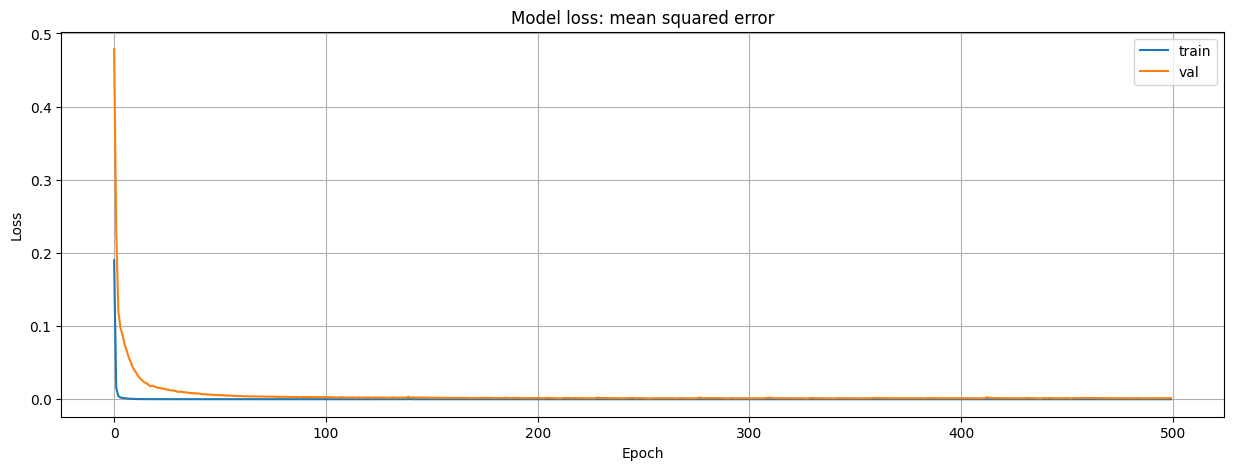

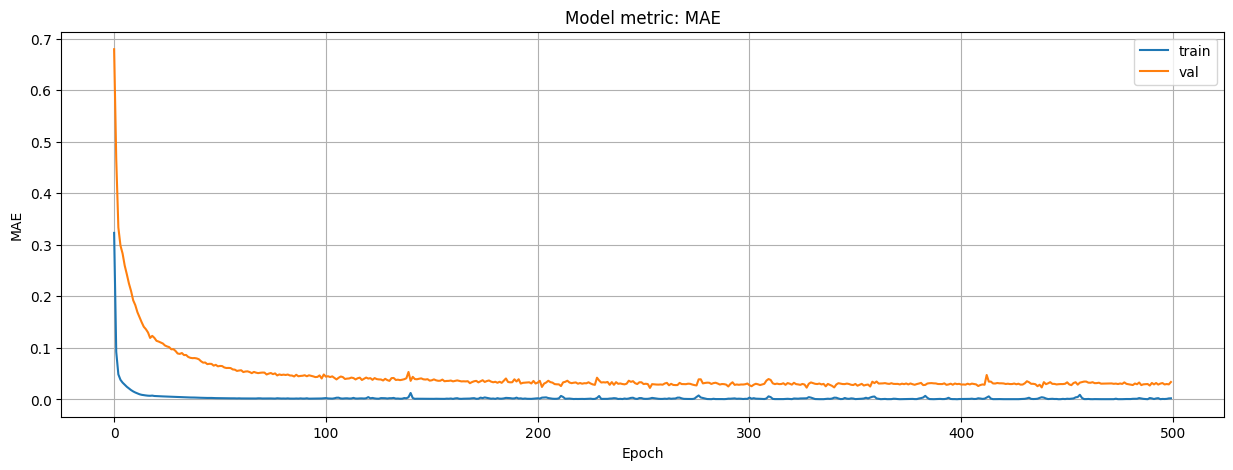

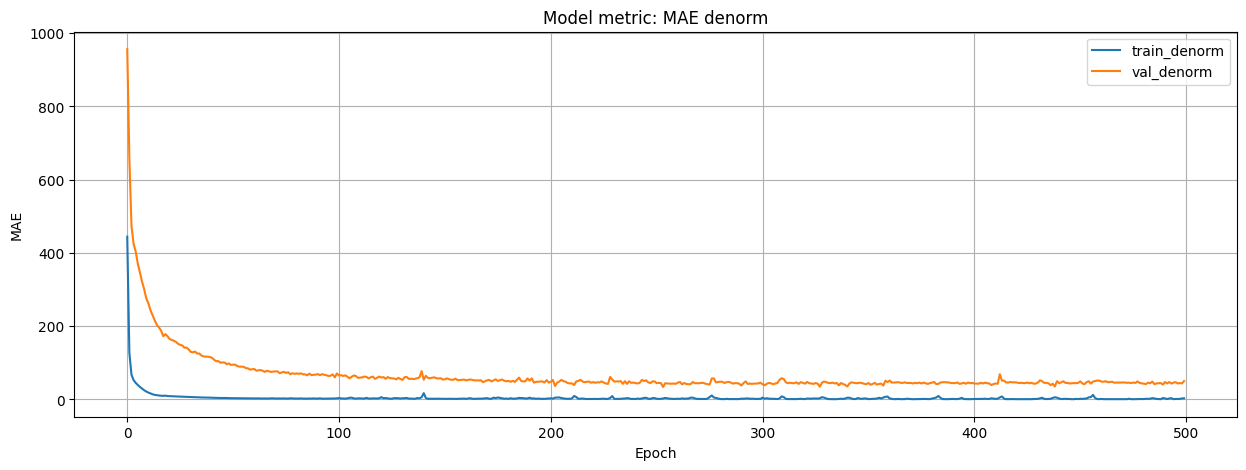

In [20]:
# Plot training & validation loss values
plt.figure(figsize=(15,5))
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Model loss: mean squared error')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.grid()
plt.show()

# Plot training & validation mae values
plt.figure(figsize=(15,5))
plt.plot(hist.history['mae'])
plt.plot(hist.history['val_mae'])
plt.title('Model metric: MAE')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.grid()
plt.show()

# Plot training & validation mae_denorm values
plt.figure(figsize=(15,5))
plt.plot(hist.history['mae_denorm'])
plt.plot(hist.history['val_mae_denorm'])
plt.title('Model metric: MAE denorm')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend(['train_denorm', 'val_denorm'], loc='upper right')
plt.grid()
plt.show()

# 5. Evaluation

- In actual inferencing, the unified model of `seq2seq_model` is no use as `encoder_model` and `decoder_model` are the ones applied for autoregressive decoding.
- Hence, the actual model evaluation should be done in the autoregressive manner as shown in Section 6.3.

In [21]:
# Load the model from the best epoch (minimum val_loss)
import os
bestmodel_path = max( [ f for f in os.listdir(".") if f.startswith('RNN_ex6_bestmodel_') and f.endswith(".keras") ] )
print( f"The best model: {bestmodel_path}" )

best_model = keras.models.load_model(bestmodel_path, compile=True )

The best model: RNN_ex6_bestmodel_epoch495.keras


In [22]:
# Evaluate the model from the last epoch
score = seq2seq_model.evaluate( [encoder_x_test_norm,decoder_x_test_norm], decoder_y_test_norm, verbose=0, return_dict=True )
print( "Test results (model from the last epoch):", score )

# Evaluate the model from the best epoch
score = best_model.evaluate( [encoder_x_test_norm,decoder_x_test_norm], decoder_y_test_norm, verbose=0, return_dict=True )
print( "Test results (model from the best epoch):", score )

Test results (model from the last epoch): {'loss': 0.040859054774045944, 'mae': 0.18935681879520416, 'mae_denorm': 274.49041748046875}
Test results (model from the best epoch): {'loss': 0.03952697664499283, 'mae': 0.1710607260465622, 'mae_denorm': 249.3955078125}


# 6. Inference

## 6.1 Load the best encoder and decoder models

In [23]:
# Load the encoder and decoder models corresponding to the best epoch (minimum val_loss)
best_encoder = keras.models.load_model( 'RNN_ex6_bestencoder.keras', compile=False )
best_decoder = keras.models.load_model( 'RNN_ex6_bestdecoder.keras', compile=False )

## 6.2 Define a function for autoregressive decoding

In [24]:
def autoregressive_decode( encoder_inf, decoder_inf, input_seq, n_step_out, n_out_feature=1, start_token=0 ):
    """
    Input arguments:
        encoder_inf (model): the encoder model to be used during inferencing
        decoder_inf (model): the decoder model to be used during inferencing
        input_seq (a sequence of numbers): an input sequence (input_dim=1) for the model to predict the next numbers
        n_step_out (int): for how many output time steps that the model should predict?
        n_out_feature (int): the number of features for one output (in our example, it is 1)
    """
    # Encode
    state = encoder_inf.predict(input_seq, verbose=0)

    # Create the first input of the decoder (= the start token)
    target_seq = np.zeros(n_out_feature).reshape(1,1,n_out_feature)
    target_seq[0,0,:] = start_token

    # Collect predictions from autoregressive decoding
    output = []
    for t in range(n_step_out):
        # Predict the next number
        y_pred, state = decoder_inf.predict([target_seq,state], verbose=0)

        # Store prediction
        output.append( y_pred[0,0,:] )

        # Update target sequence
        target_seq = y_pred

    return np.array(output)

## 6.3 Evaluation with autoregressive decoding

In [25]:
def autoregressive_mae(encx, encx_norm, decy, decy_norm, n_step_out, print_each_sample=True):
    n = 100    # evaluate the first n data of the set
    mae_loss_norm = 0.0
    mae_loss = 0.0

    mae_norm_list = []
    mae_list = []
    for i in range(n):
        ypred_norm = autoregressive_decode( best_encoder, best_decoder,
                                            np.expand_dims(encx_norm[i],axis=0),
                                            n_step_out, 1, start_token_norm)

        # Denormalize with train statistics
        ypred = (ypred_norm * train_std) + train_mean

        # Compute MAE
        mae_norm = np.mean(np.abs(ypred_norm - decy_norm[i]))
        mae = np.mean(np.abs(ypred - decy[i]))
        mae_norm_list.append(mae_norm)
        mae_list.append(mae)

        if (print_each_sample):
            print( f'encoder_x[{i}] = {encx[i].ravel()}' )
            print( f'decoder_y[{i}] = {decy[i].ravel()}' )
            print( f'predict = {ypred.reshape(-1)} =round=> {np.around(ypred.reshape(-1))}\n' )

    # Overall MAE
    mae_loss_norm = np.mean(mae_norm_list)
    mae_loss = np.mean(mae_list)
    print(f"TOTAL LOSS (MAE) normalized = {mae_loss_norm:.4f}")
    print(f"TOTAL LOSS (MAE) denormalized = {mae_loss:.4f}")

Evaluate the models on the train set:

In [26]:
autoregressive_mae(encoder_x_train, encoder_x_train_norm, decoder_y_train, decoder_y_train_norm, n_output_timesteps, print_each_sample=True)

encoder_x[0] = [-4000. -3998. -3996. -3994. -3992.]
decoder_y[0] = [-3990. -3988. -3986.]
predict = [-3997.00665771 -4003.56930769 -4001.96077294] =round=> [-3997. -4004. -4002.]

encoder_x[1] = [-3998. -3996. -3994. -3992. -3990.]
decoder_y[1] = [-3988. -3986. -3984.]
predict = [-3995.08791263 -4001.61884781 -4000.08926969] =round=> [-3995. -4002. -4000.]

encoder_x[2] = [-3996. -3994. -3992. -3990. -3988.]
decoder_y[2] = [-3986. -3984. -3982.]
predict = [-3993.16850683 -3999.66789239 -3998.21694053] =round=> [-3993. -4000. -3998.]

encoder_x[3] = [-3994. -3992. -3990. -3988. -3986.]
decoder_y[3] = [-3984. -3982. -3980.]
predict = [-3991.24844029 -3997.71594588 -3996.34328992] =round=> [-3991. -3998. -3996.]

encoder_x[4] = [-3992. -3990. -3988. -3986. -3984.]
decoder_y[4] = [-3982. -3980. -3978.]
predict = [-3989.32738267 -3995.76317347 -3994.46815268] =round=> [-3989. -3996. -3994.]

encoder_x[5] = [-3990. -3988. -3986. -3984. -3982.]
decoder_y[5] = [-3980. -3978. -3976.]
predict = 

Evaluate the models on the val set:

In [27]:
autoregressive_mae(encoder_x_val, encoder_x_val_norm, decoder_y_val, decoder_y_val_norm, n_output_timesteps, print_each_sample=True)

encoder_x[0] = [790. 792. 794. 796. 798.]
decoder_y[0] = [800. 802. 804.]
predict = [805.43900819 811.21093566 818.87303185] =round=> [805. 811. 819.]

encoder_x[1] = [792. 794. 796. 798. 800.]
decoder_y[1] = [802. 804. 806.]
predict = [807.34635577 813.09102833 820.7418922 ] =round=> [807. 813. 821.]

encoder_x[2] = [794. 796. 798. 800. 802.]
decoder_y[2] = [804. 806. 808.]
predict = [809.25353817 814.97095583 822.60976147] =round=> [809. 815. 823.]

encoder_x[3] = [796. 798. 800. 802. 804.]
decoder_y[3] = [806. 808. 810.]
predict = [811.15906875 816.84873597 824.4753182 ] =round=> [811. 817. 824.]

encoder_x[4] = [798. 800. 802. 804. 806.]
decoder_y[4] = [808. 810. 812.]
predict = [813.06410379 818.72552502 826.34004902] =round=> [813. 819. 826.]

encoder_x[5] = [800. 802. 804. 806. 808.]
decoder_y[5] = [810. 812. 814.]
predict = [814.96814775 820.60099262 828.20279767] =round=> [815. 821. 828.]

encoder_x[6] = [802. 804. 806. 808. 810.]
decoder_y[6] = [812. 814. 816.]
predict = [816

Evaluate the models on the test set:

In [28]:
autoregressive_mae(encoder_x_test, encoder_x_test_norm, decoder_y_test, decoder_y_test_norm, n_output_timesteps, print_each_sample=True)

encoder_x[0] = [1392. 1394. 1396. 1398. 1400.]
decoder_y[0] = [1402. 1404. 1406.]
predict = [1319.10404736 1292.22344627 1286.77345701] =round=> [1319. 1292. 1287.]

encoder_x[1] = [1394. 1396. 1398. 1400. 1402.]
decoder_y[1] = [1404. 1406. 1408.]
predict = [1320.54442762 1293.46990378 1287.95681529] =round=> [1321. 1293. 1288.]

encoder_x[2] = [1396. 1398. 1400. 1402. 1404.]
decoder_y[2] = [1406. 1408. 1410.]
predict = [1321.9828257  1294.71404874 1289.13753067] =round=> [1322. 1295. 1289.]

encoder_x[3] = [1398. 1400. 1402. 1404. 1406.]
decoder_y[3] = [1408. 1410. 1412.]
predict = [1323.41924162 1295.95555081 1290.31593351] =round=> [1323. 1296. 1290.]

encoder_x[4] = [1400. 1402. 1404. 1406. 1408.]
decoder_y[4] = [1410. 1412. 1414.]
predict = [1324.85334499 1297.19440998 1291.49169345] =round=> [1325. 1297. 1291.]

encoder_x[5] = [1402. 1404. 1406. 1408. 1410.]
decoder_y[5] = [1412. 1414. 1416.]
predict = [1326.28546619 1298.43095662 1292.66448013] =round=> [1326. 1298. 1293.]

enco